In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import load_data, clean_data, prepare_train_test_data

df = load_data("../data/raw/telco_churn.csv")
df = clean_data(df)

X_train, X_test, y_train, y_test, preprocessor = prepare_train_test_data(df)

print("Train shape:", X_train.shape)

Train shape: (5634, 46)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

best_rf = grid_search.best_estimator_

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.86275694014269


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nTuned Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Tuned Random Forest Performance
Accuracy: 0.7700496806245565
Precision: 0.5504032258064516
Recall: 0.7299465240641712
F1 Score: 0.6275862068965518
ROC-AUC: 0.8503048386680101


In [4]:
threshold = 0.3
adjusted_preds = (y_prob >= threshold).astype(int)

print("\nThreshold 0.3 Performance")
print("Precision:", precision_score(y_test, adjusted_preds))
print("Recall:", recall_score(y_test, adjusted_preds))
print("F1 Score:", f1_score(y_test, adjusted_preds))


Threshold 0.3 Performance
Precision: 0.46799431009957326
Recall: 0.8796791443850267
F1 Score: 0.6109563602599815


In [5]:
import pandas as pd
import numpy as np

feature_names = preprocessor.get_feature_names_out()

importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
37,cat__Contract_Month-to-month,0.119236
1,num__Tenure Months,0.107004
3,num__Total Charges,0.085834
2,num__Monthly Charges,0.065455
39,cat__Contract_Two year,0.055354
4,num__CLTV,0.050928
19,cat__Online Security_No,0.050432
28,cat__Tech Support_No,0.047357
9,cat__Dependents_No,0.043554
10,cat__Dependents_Yes,0.039754


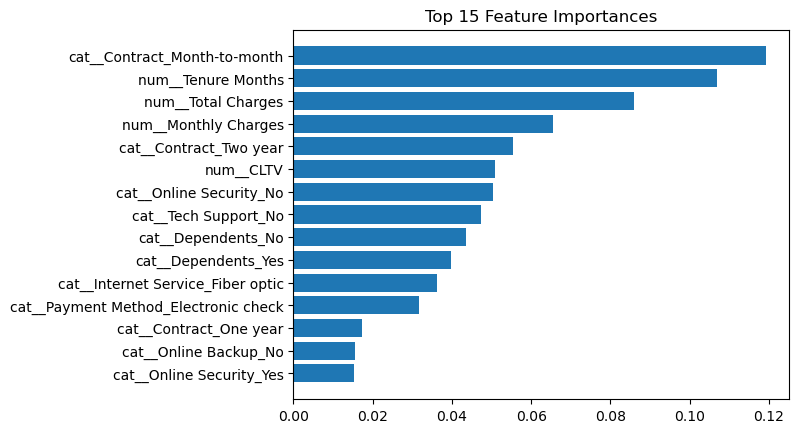

In [6]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

In [7]:
import joblib

joblib.dump(best_rf, "../models/random_forest_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.
